In [1]:
# ==============================================================
# FRB ISOTROPY TEST — FULL PIPELINE (WITH SELECTION FUNCTION)
# ==============================================================

import numpy as np
import pandas as pd
import treecorr
import healpy as hp
import os
from tqdm.auto import tqdm
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

In [2]:
# ==============================================================
# 1. CONFIGURAÇÕES GERAIS
# ==============================================================

BASE_PATH = "/home/brunowesley/projetos/FRB-isotropy-tests/FRB_catalogs/"

N_RAND_FACTOR = 20     # número de randoms por objeto real
N_MOCKS = 200          # número de simulações H0
NSIDE = 32             # resolução HEALPix (função de seleção)

USE_GAL_MASK = True
GAL_CUT = 20.0

MIN_SEP = 0.1
MAX_SEP = 180.0
BIN_SIZE = 1.8
N_BINS = int((MAX_SEP - MIN_SEP) / BIN_SIZE)

COARSE_BINS = np.arange(0, 181, 20)
COARSE_CENTERS = 0.5 * (COARSE_BINS[:-1] + COARSE_BINS[1:])

In [3]:
# ==============================================================
# 2. FUNÇÃO DE MÁSCARA (FÍSICA)
# ==============================================================

def apply_mask(df):
    """
    Remove regiões inválidas e aplica corte galáctico.
    """
    mask = (
        (df["RA"] >= 0) & (df["RA"] <= 360) &
        (df["DEC"] >= -90) & (df["DEC"] <= 90)
    )

    df = df[mask].copy()

    if USE_GAL_MASK:
        coords = SkyCoord(
            ra=df['RA'].values * u.degree,
            dec=df['DEC'].values * u.degree,
            frame='icrs'
        )
        b = coords.galactic.b.degree
        df = df[np.abs(b) > GAL_CUT]

    return df.reset_index(drop=True)

In [4]:
# ==============================================================
# 3. FUNÇÃO DE SELEÇÃO (CRUCIAL)
# ==============================================================

def build_selection_function(df, nside):
    """
    Constrói mapa de densidade HEALPix a partir dos dados.
    Isso representa a função de seleção instrumental.
    """
    theta = np.radians(90.0 - df["DEC"].values)
    phi = np.radians(df["RA"].values)

    pix = hp.ang2pix(nside, theta, phi)

    npix = hp.nside2npix(nside)
    density = np.bincount(pix, minlength=npix)

    return density


# ==============================================================
# 4. RANDOMS COM FUNÇÃO DE SELEÇÃO
# ==============================================================

def generate_randoms_from_selection(n, density, nside, seed=None):
    """
    Gera catálogo aleatório respeitando a função de seleção.
    """
    
    rng = np.random.default_rng(seed)

    prob = density / np.sum(density)

    pix_choices = rng.choice(len(prob), size=n, p=prob)

    theta, phi = hp.pix2ang(nside, pix_choices)

    ra = np.degrees(phi)
    dec = 90.0 - np.degrees(theta)

    return pd.DataFrame({"RA": ra, "DEC": dec})

In [5]:
# ==============================================================
# 5. 2pACF (LANDY–SZALAY)
# ==============================================================

def compute_2pacf(df_data, df_rand):

    cat_data = treecorr.Catalog(
        ra=df_data["RA"], dec=df_data["DEC"],
        ra_units="deg", dec_units="deg"
    )

    cat_rand = treecorr.Catalog(
        ra=df_rand["RA"], dec=df_rand["DEC"],
        ra_units="deg", dec_units="deg"
    )

    nn = treecorr.NNCorrelation(
        min_sep=MIN_SEP,
        max_sep=MAX_SEP,
        nbins=N_BINS,
        sep_units="deg",
        metric='Arc',
        bin_type='Linear'
    )

    rr = treecorr.NNCorrelation(**nn.config)
    dr = treecorr.NNCorrelation(**nn.config)

    nn.process(cat_data)
    rr.process(cat_rand)
    dr.process(cat_data, cat_rand)

    nn.calculateXi(rr=rr, dr=dr)

    theta = np.exp(nn.meanlogr)
    return theta, nn.xi

In [6]:
# ==============================================================
# 6. ESTATÍSTICA RESUMO
# ==============================================================

def get_absolute_sum(theta, w):
    vals = []

    for i in range(len(COARSE_BINS) - 1):
        mask = (theta >= COARSE_BINS[i]) & (theta < COARSE_BINS[i+1])

        if np.any(mask):
            vals.append(np.abs(np.mean(w[mask])))
        else:
            vals.append(0.0)

    return np.array(vals)

In [7]:
# ==============================================================
# 7. CARREGAR DADOS
# ==============================================================

def load_catalog(path):
    df = pd.read_csv(path)

    # garantir que RA/DEC existem
    if not {"RA", "DEC"}.issubset(df.columns):
        raise ValueError("Arquivo precisa conter colunas RA e DEC")

    df = df[["RA", "DEC"]].copy()

    # remover NaNs
    df = df.dropna()

    # garantir floats
    df["RA"] = df["RA"].astype(float)
    df["DEC"] = df["DEC"].astype(float)

    # normalizar RA (caso venha fora do range)
    df["RA"] = df["RA"] % 360

    return df

In [8]:
# ==============================================================
# 8. JACKKNIFE (HEALPix)
# ==============================================================

def assign_jk_regions(df, nside=2):
    theta = np.radians(90.0 - df["DEC"].values)
    phi = np.radians(df["RA"].values)

    pix = hp.ang2pix(nside, theta, phi)

    df = df.copy()
    df["jk_region"] = pix

    return df

def jackknife_full(df_data, selection_density):

    df = assign_jk_regions(df_data, nside=2)
    regions = np.unique(df["jk_region"])

    jk_w = []

    for region in tqdm(regions):

        df_jk = df[df["jk_region"] != region]

        if len(df_jk) < 50:
            continue

        df_rand = generate_randoms_from_selection(
            len(df_jk) * N_RAND_FACTOR,
            selection_density,
            NSIDE,
            seed=1000 + int(region)
        )

        theta, w = compute_2pacf(df_jk, df_rand)
        jk_w.append(w)

    jk_w = np.array(jk_w)

    mean_w = np.mean(jk_w, axis=0)

    cov = (len(jk_w)-1)/len(jk_w) * np.sum(
        [(w - mean_w)[:, None] @ (w - mean_w)[None, :]
         for w in jk_w],
        axis=0
    )

    err = np.sqrt(np.diag(cov))

    return {"cov": cov, "err": err}


--- Loading full catalog ---


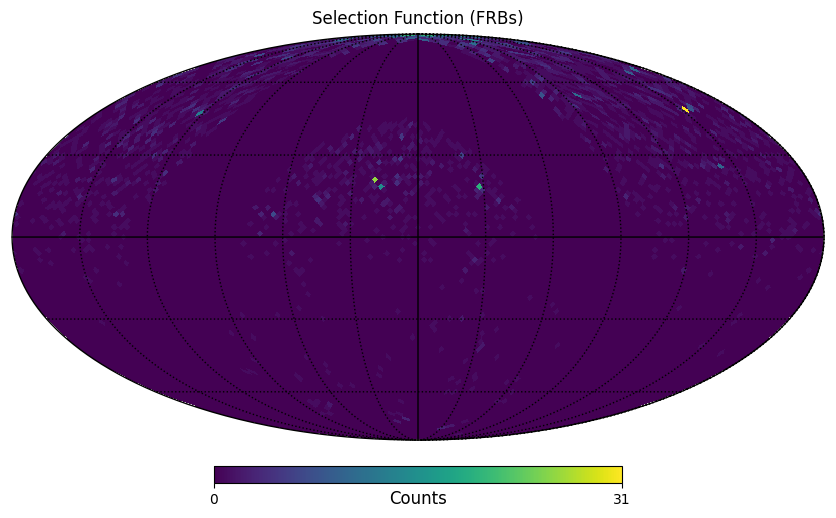

In [9]:
# ==============================================================
# 9. DADOS OBSERVACIONAIS (CATÁLOGO ÚNICO)
# ==============================================================

FULL_CATALOG_PATH = os.path.join(BASE_PATH, "SkyPosition.csv")

print("\n--- Loading full catalog ---")

df_data = apply_mask(load_catalog(FULL_CATALOG_PATH))

# ==============================================================
# 10. FUNÇÃO DE SELEÇÃO
# ==============================================================

selection_density = build_selection_function(df_data, NSIDE)


# --- Visualização da função de seleção ---

hp.mollview(selection_density,
            title="Selection Function (FRBs)",
            unit="Counts",
            cmap="viridis")
hp.graticule()

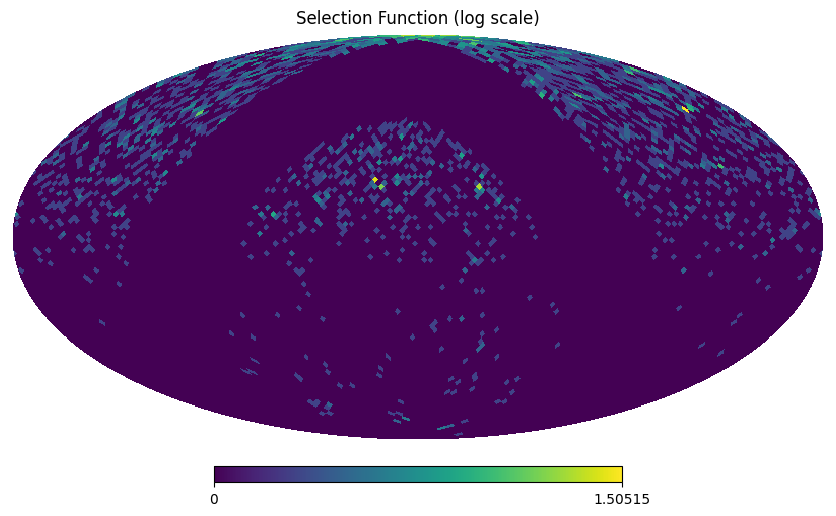

In [15]:
hp.mollview(np.log10(selection_density + 1),
            title="Selection Function (log scale)",
            cmap="viridis")

In [10]:
# ==============================================================
# 11. RANDOMS DOS DADOS
# ==============================================================

df_rand = generate_randoms_from_selection(
    len(df_data) * N_RAND_FACTOR,
    selection_density,
    NSIDE,
    seed=42
)

# ==============================================================
# 12. 2pACF OBSERVADA
# ==============================================================

print("\n--- Computing observed 2pACF ---")

theta, w_obs = compute_2pacf(df_data, df_rand)

abs_obs = get_absolute_sum(theta, w_obs)

# ==============================================================
# 13. JACKKNIFE
# ==============================================================

print("\n--- Jackknife ---")

jk = jackknife_full(df_data, selection_density)


--- Computing observed 2pACF ---

--- Jackknife ---


  0%|          | 0/42 [00:00<?, ?it/s]

In [11]:
# ==============================================================
# 14. MOCKS H0
# ==============================================================

print("\n--- Generating H0 mocks ---")

all_w_h0 = []
all_abs_h0 = []

n_data = len(df_data)

for i in tqdm(range(N_MOCKS)):

    d_iso = generate_randoms_from_selection(
        n_data,
        selection_density,
        NSIDE,
        seed=i
    )

    r_iso = generate_randoms_from_selection(
        n_data * N_RAND_FACTOR,
        selection_density,
        NSIDE,
        seed=i + 10000
    )

    _, w = compute_2pacf(d_iso, r_iso)

    all_w_h0.append(w)
    all_abs_h0.append(get_absolute_sum(theta, w))

all_w_h0 = np.array(all_w_h0)
all_abs_h0 = np.array(all_abs_h0)

h0_mean = np.mean(all_w_h0, axis=0)
h0_std = np.std(all_w_h0, axis=0)

h0_abs_mean = np.mean(all_abs_h0, axis=0)
h0_abs_std = np.std(all_abs_h0, axis=0)


--- Generating H0 mocks ---


  0%|          | 0/200 [00:00<?, ?it/s]

In [12]:
# ==============================================================
# 15. TESTES ESTATÍSTICOS
# ==============================================================

print("\n--- Statistical tests ---")

cov = jk["cov"]
inv_cov = np.linalg.pinv(cov)

delta = w_obs - h0_mean

chi2 = delta @ inv_cov @ delta
dof = len(delta)

print(f"Chi2/dof = {chi2/dof:.2f}")

ks_stat, ks_p = ks_2samp(abs_obs, h0_abs_mean)
print(f"KS p-value = {ks_p:.4e}")


--- Statistical tests ---
Chi2/dof = 1.20
KS p-value = 6.2937e-03


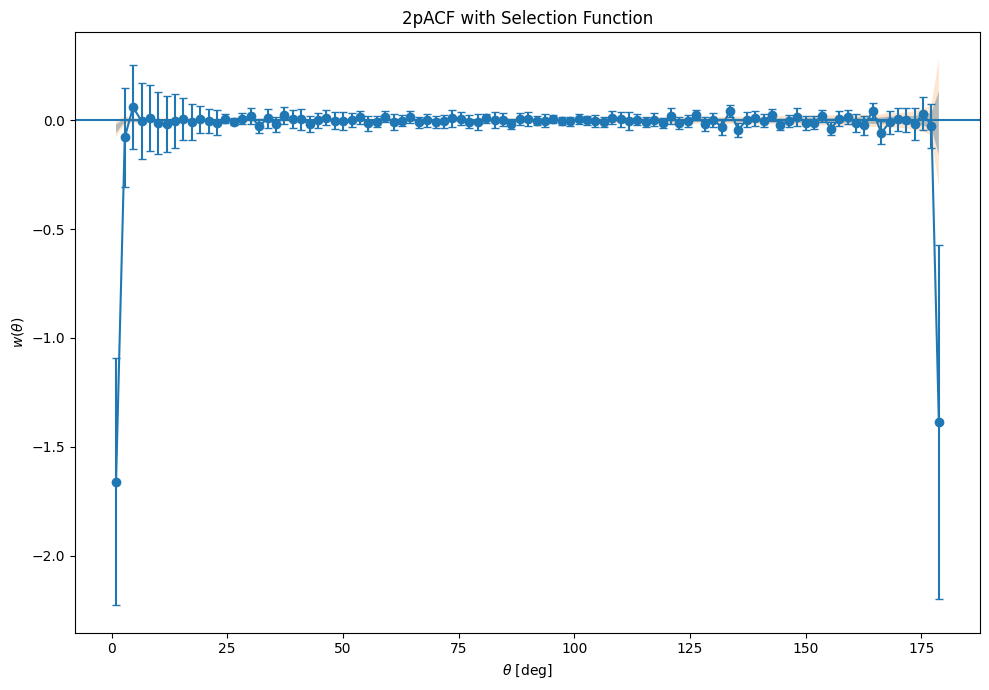

In [13]:
# ==============================================================
# 16. PLOT — 2pACF
# ==============================================================

plt.figure(figsize=(10, 7))

plt.fill_between(theta, h0_mean - h0_std, h0_mean + h0_std, alpha=0.4)
plt.fill_between(theta, h0_mean - 2*h0_std, h0_mean + 2*h0_std, alpha=0.2)

plt.errorbar(theta, w_obs, yerr=jk["err"], fmt='o-', capsize=3)

plt.axhline(0)

plt.xlabel(r'$\theta$ [deg]')
plt.ylabel(r'$w(\theta)$')

plt.title('2pACF with Selection Function')

plt.tight_layout()
plt.show()

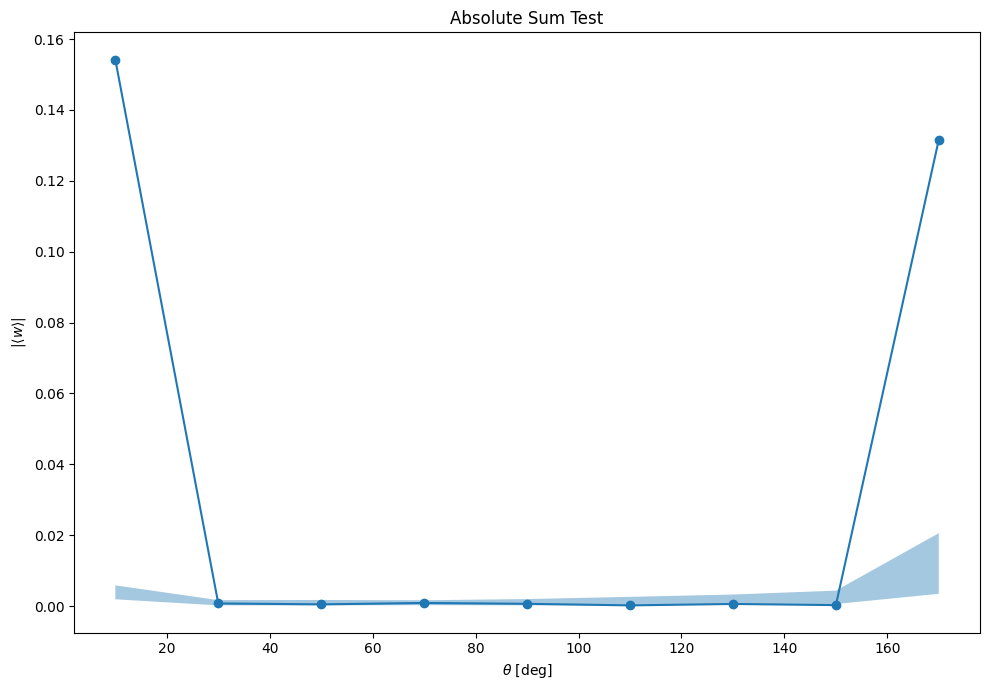

In [14]:
# ==============================================================
# 17. PLOT — ABSOLUTE SUM
# ==============================================================

plt.figure(figsize=(10, 7))

plt.fill_between(COARSE_CENTERS,
                 h0_abs_mean - h0_abs_std,
                 h0_abs_mean + h0_abs_std,
                 alpha=0.4)

plt.errorbar(COARSE_CENTERS, abs_obs, fmt='o-', capsize=3)

plt.xlabel(r'$\theta$ [deg]')
plt.ylabel(r'$|\langle w \rangle|$')

plt.title('Absolute Sum Test')

plt.tight_layout()
plt.show()